# `kamo.hamiltonian` — magnetic and laser sweeps, manifolds, and state labels

A tour of the multi-manifold structure calculator: how a basis is built from
fine-structure manifolds, how a magnetic-field or laser-intensity sweep tracks
every eigenstate, what the plot arguments do (`states=`, `xlim=`,
`plot_differential=`, `coupled_labels=`), and what a state label means once
the field mixes the zero-field hyperfine states.

1. **Setup** — the atom object and what it supplies.
2. **Manifolds and the basis** — `AtomicStructure`, `Manifold`, `make_nlj_basis`, `model.states(...)`.
3. **Magnetic sweep** — `magnetic_sweep`, the plot arguments, reading numbers back out.
4. **State labels and the adiabatic connection** — why a label is a property of the whole sweep.
5. **Laser sweep** — light shifts at a fixed field, choosing the basis and the model.
6. **A different atom** — Rb87, Cs, and the integer-nuclear-spin case (Li6, K40).
7. **Things worth knowing** — a checklist collected while writing this notebook.

Conventions: energies are stored in Hz (as $E/h$) and plotted in the unit you
ask for; magnetic fields are in Gauss; intensities in W/m² (plot in mW/cm²
with `x_unit`). A state is a 5-tuple `(n, l, j, a, b)`: two **integers** are
zero-field `(F, m_F)` labels, two **half-integers** are high-field
`(m_J, m_I)` labels (for half-integer nuclear spin; section 6 covers the
integer-spin case).

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from kamo import Potassium39, GaussianBeam
from kamo.hamiltonian import (AtomicStructure, Manifold, make_nlj_basis,
                              light_shift_basis, choose_laser_model,
                              state_label, is_coupled)

plt.rcParams["figure.figsize"] = (7, 4.2)
plt.rcParams["figure.dpi"] = 100

## 1. Setup: the atom

Every calculation reads its data from an **atom object**. `Potassium39()` is
kamo's default: ARC's 39K (NIST energies) with E1 matrix elements, transition
rates and lifetimes from the UDel portal, kamo's curated hyperfine constants,
and the measured nuclear and ground-state g-factors. Building one opens ARC's
database once; reuse the same instance everywhere.

In [2]:
atom = Potassium39()
print(atom)
print("nuclear spin I =", atom.I, "  g_I =", atom.gI, "  g_J(4S1/2) =", atom.g_J(0, 0.5))
print("ground state (n, l, j) =", atom.ground_state)
for nlj in [(4, 0, 0.5), (4, 1, 0.5), (4, 1, 1.5), (3, 2, 2.5)]:
    print(atom.hyperfine_constants(*nlj))

Potassium39(use_portal=True, portal_species='K1')
nuclear spin I = 1.5   g_I = -0.00014193489   g_J(4S1/2) = 2.00229421
ground state (n, l, j) = (4, 0, 0.5)
39K 4s1/2: A = 230.85986(3e-07) MHz [measured], B = 0(0) MHz [exact (J = 1/2)]
39K 4p1/2: A = 27.793(0.071) MHz [measured], B = 0(0) MHz [exact (J = 1/2)]
39K 4p3/2: A = 6.084(0.017) MHz [measured], B = 2.842(0.043) MHz [measured]
39K 3d5/2: A = -0.62(0.04) MHz [measured], B = 0(0.3) MHz [bound]


## 2. Manifolds and the basis

A **manifold** is one fine-structure level `(n, l, j)`; its basis states are
the uncoupled sublevels $|m_J, m_I\rangle$, so it has $(2j+1)(2I+1)$ of them
(8 for $4S_{1/2}$, 16 for $4P_{3/2}$ with $I = 3/2$). `AtomicStructure` takes a
list of manifolds (tuples or `Manifold` objects) and builds the Hamiltonian:
fine structure + hyperfine $A\,\mathbf{I}\cdot\mathbf{J}$ (+ quadrupole $B$).
Fine-structure energies are referenced to the **first** manifold in the list.

In [3]:
model = AtomicStructure([(4, 0, 0.5), (4, 1, 0.5), (4, 1, 1.5)], atom=atom)

print("basis dimension:", model.basis.dim)
for man in model.basis.manifolds:
    print(f"  {man!r}: allowed F = {man.allowed_F()}, F by energy = {man.F_order()}")

# manifolds are indexable by position or by (n, l, j)
print(model[0], model[(4, 1, 1.5)])

basis dimension: 32
  Manifold(n=4, l=0, j=0.5, I=1.5, dim=8): allowed F = [1.0, 2.0], F by energy = [1.0, 2.0]
  Manifold(n=4, l=1, j=0.5, I=1.5, dim=8): allowed F = [1.0, 2.0], F by energy = [1.0, 2.0]
  Manifold(n=4, l=1, j=1.5, I=1.5, dim=16): allowed F = [0.0, 1.0, 2.0, 3.0], F by energy = [0.0, 1.0, 2.0, 3.0]
Manifold(n=4, l=0, j=0.5, I=1.5, dim=8) Manifold(n=4, l=1, j=1.5, I=1.5, dim=16)


`make_nlj_basis(n, l, n_range, l_range)` (or `AtomicStructure.around(...)`)
generates the tuples for you and leaves out **core orbitals** (for potassium
3s, 3p and below), which are not valence states. Which n are core is read
from the atom, so the same call works for rubidium (where 4s and 4p are core).

In [4]:
print("around 4S, l ±1:        ", make_nlj_basis(4, 0))
print("around 4S, n ±1, l ±1:  ", make_nlj_basis(4, 0, n_range=1))
print("around 3D, l ±1:        ", make_nlj_basis(3, 2))   # 3p is a core orbital and is left out
print("around 4P, n ±1, l ±2:  ", make_nlj_basis(4, 1, n_range=1, l_range=2))

around 4S, l ±1:         [(4, 0, 0.5), (4, 1, 0.5), (4, 1, 1.5)]
around 4S, n ±1, l ±1:   [(4, 0, 0.5), (4, 1, 0.5), (4, 1, 1.5), (5, 0, 0.5), (5, 1, 0.5), (5, 1, 1.5)]
around 3D, l ±1:         [(3, 2, 1.5), (3, 2, 2.5)]
around 4P, n ±1, l ±2:   [(3, 2, 1.5), (3, 2, 2.5), (4, 0, 0.5), (4, 1, 0.5), (4, 1, 1.5), (4, 2, 1.5), (4, 2, 2.5), (4, 3, 2.5), (4, 3, 3.5), (5, 0, 0.5), (5, 1, 0.5), (5, 1, 1.5), (5, 2, 1.5), (5, 2, 2.5), (5, 3, 2.5), (5, 3, 3.5)]


`model.states(...)` lists basis states as `(n, l, j, m_j, m_i)` 5-tuples with
optional filters. `F=` and `mF=` filters are resolved through the manifold's
Paschen–Back label map (section 4), so `model.states(F=1)` gives the eight
high-field states that *connect to* the zero-field $F=1$ multiplet. The list
can be passed straight to `plot(states=...)`.

In [5]:
print("ground manifold, m_J = +1/2:", model.states(n=4, l=0, mJ=0.5))
print("|F=1, m_F=-1> in every manifold:", model.states(F=1, mF=-1))
print("4P3/2 states with m_F = -1:", model.states(n=4, l=1, j=1.5, mF=-1))

ground manifold, m_J = +1/2: [(4, 0, 0.5, 0.5, -1.5), (4, 0, 0.5, 0.5, -0.5), (4, 0, 0.5, 0.5, 0.5), (4, 0, 0.5, 0.5, 1.5)]
|F=1, m_F=-1> in every manifold: [(4, 0, 0.5, -0.5, -0.5), (4, 1, 0.5, -0.5, -0.5), (4, 1, 1.5, -1.5, 0.5)]
4P3/2 states with m_F = -1: [(4, 1, 1.5, -1.5, 0.5), (4, 1, 1.5, -0.5, -0.5), (4, 1, 1.5, 0.5, -1.5)]


## 3. Magnetic sweep

`magnetic_sweep(B_max, dB)` diagonalizes $H_0 + B\,H_Z$ on a grid from 0 to
`B_max` and **tracks** each eigenstate from step to step (eigenshuffle), so a
state keeps its identity through avoided crossings. The result holds
`energies` (steps × states, in Hz), `param` (the field grid) and the
eigenvectors.

`dB` matters: tracking needs the eigenvectors to change little between steps.
The Breit–Rabi region of a manifold with hyperfine constant $A$ spans roughly
$A / (1.4\ \mathrm{MHz/G})$, so keep `dB` a few percent of that. A
`RuntimeWarning` is raised if a state cannot be followed.

In [6]:
res = model.magnetic_sweep(B_max=600.0, dB=0.5)
print("energies:", res.energies.shape, " field grid:", res.param.shape, " max field:", res.param[-1], "G")

energies: (1201, 32)  field grid: (1201,)  max field: 600.0 G


### 3.1 `states=` selects what to draw

Anything the sweep understands as a state specifier works: a manifold object,
an `(n, l, j)` tuple, an `(n, l, j, F_or_m_J)` 4-tuple, a 5-tuple for a single
state, a list mixing these, or plain integer indices.

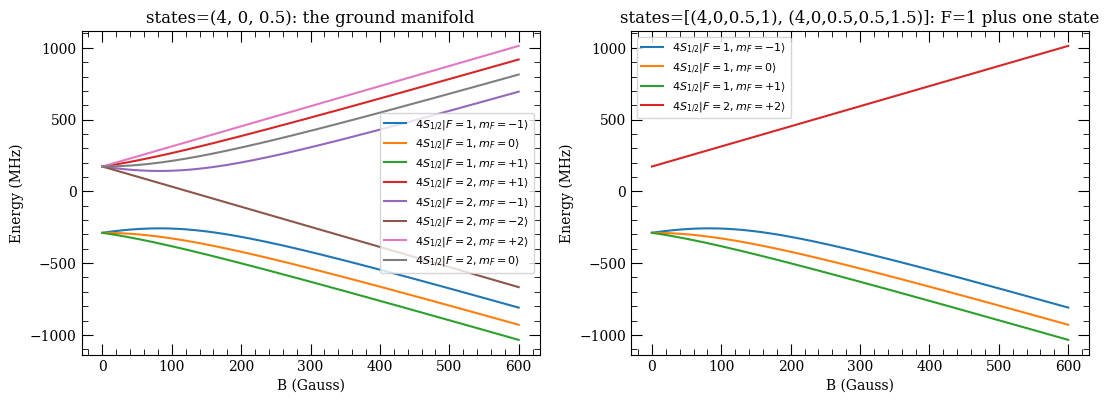

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
res.plot(ax=ax[0], states=(4, 0, 0.5), coupled_labels=True)
ax[0].set_title("states=(4, 0, 0.5): the ground manifold")
res.plot(ax=ax[1], states=[(4, 0, 0.5, 1), (4, 0, 0.5, 0.5, 1.5)], coupled_labels=True)
ax[1].set_title("states=[(4,0,0.5,1), (4,0,0.5,0.5,1.5)]: F=1 plus one state");

Note the two ways a 4-tuple can be read: `(4, 0, 0.5, 1)` is "$F = 1$" and
`(4, 0, 0.5, -0.5)` is "$m_J = -1/2$" — an integer is an $F$, a half-integer
an $m_J$. The 5-tuple `(4, 0, 0.5, 0.5, 1.5)` is $|m_J=+1/2, m_I=+3/2\rangle$,
which is the stretched $|F=2, m_F=2\rangle$ state.

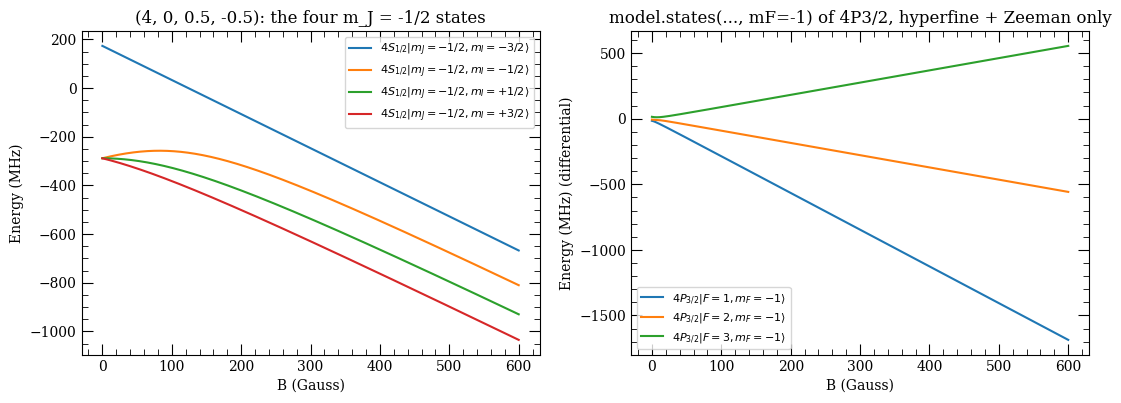

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
res.plot(ax=ax[0], states=(4, 0, 0.5, -0.5))
ax[0].set_title("(4, 0, 0.5, -0.5): the four m_J = -1/2 states")
res.plot(ax=ax[1],
         states=model.states(n=4, l=1, j=1.5, mF=-1),
         coupled_labels=True,
         plot_differential=(4, 1, 1.5))
ax[1].set_title("model.states(..., mF=-1) of 4P3/2, hyperfine + Zeeman only");

### 3.2 `plot_differential=` chooses the energy zero

* `False` — raw energies (fine structure included, so the excited manifold sits at 391 THz).
* `(n, l, j)` — subtract that manifold's zero-field centre of gravity: hyperfine + Zeeman only.
* `True` — subtract each state's own starting value: every line starts at 0.
* `(n, l, j, a, b)` — subtract one reference state's *track*: differential shifts, e.g. relative to a clock state.

`energy_unit` picks the scale ("Hz" … "THz"); `energy_offset` (Hz) is a plain
constant subtraction.

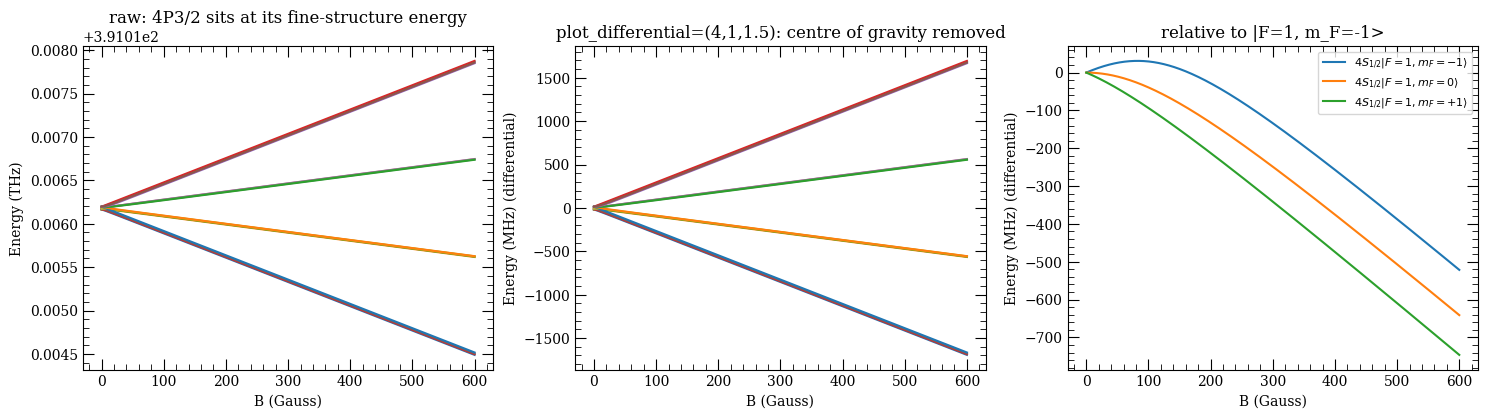

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.2))
res.plot(ax=ax[0], states=(4, 1, 1.5), energy_unit="THz", label_states=False)
ax[0].set_title("raw: 4P3/2 sits at its fine-structure energy")
res.plot(ax=ax[1], states=(4, 1, 1.5), plot_differential=(4, 1, 1.5), label_states=False)
ax[1].set_title("plot_differential=(4,1,1.5): centre of gravity removed")
res.plot(ax=ax[2], states=(4, 0, 0.5, 1), plot_differential=(4, 0, 0.5, 1, -1),
         coupled_labels=True)
ax[2].set_title("relative to |F=1, m_F=-1>");

### 3.3 `xlim=` zooms and rescales

With `xlim` the y-axis is autoscaled to the data **inside** the window, so
zooming into the Breit–Rabi region does not leave you with the full 600 G
span on the y-axis. `label_states=False` drops the legend for busy plots;
`legend=True` forces it back on. Extra keyword arguments go to `ax.plot`.

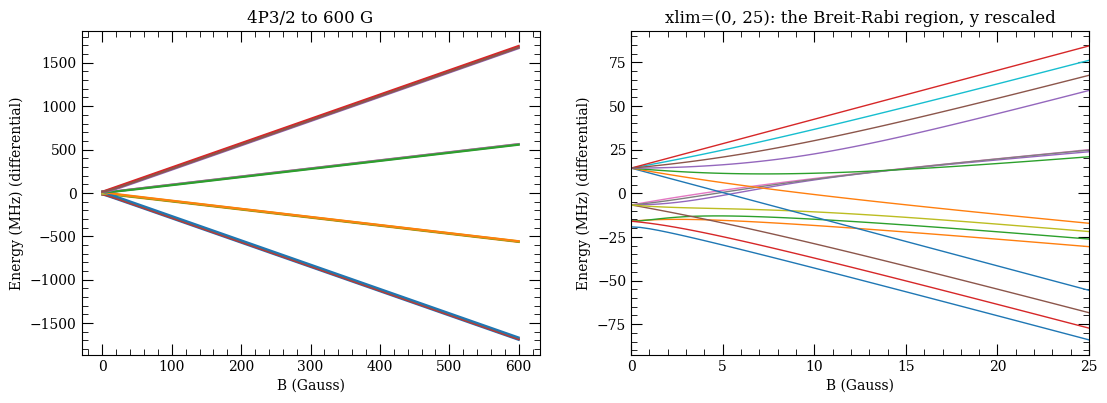

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
res.plot(ax=ax[0], states=(4, 1, 1.5), plot_differential=(4, 1, 1.5), label_states=False)
ax[0].set_title("4P3/2 to 600 G")
res.plot(ax=ax[1], states=(4, 1, 1.5), plot_differential=(4, 1, 1.5), label_states=False,
         xlim=(0, 25), lw=1.0)
ax[1].set_title("xlim=(0, 25): the Breit-Rabi region, y rescaled");

### 3.4 Reading numbers out

Energies and transition frequencies come back in Hz, at any field, with the
same state grammar. `at=` interpolates the tracked energy at a field (scalar
or array); without it you get the whole track. `field_energy` returns the
arrays and labels for your own plotting; `field_from_splitting` inverts a
measured splitting to a field.

E(|1,-1>) at 100 G = -259.1459 MHz;  via (m_J, m_I) = -259.1459 MHz
|1,-1> -> |2,-2| at 0, 100, 520.6 G: [461.72  292.198 147.259] MHz
field_from_splitting recovers 520.60 G


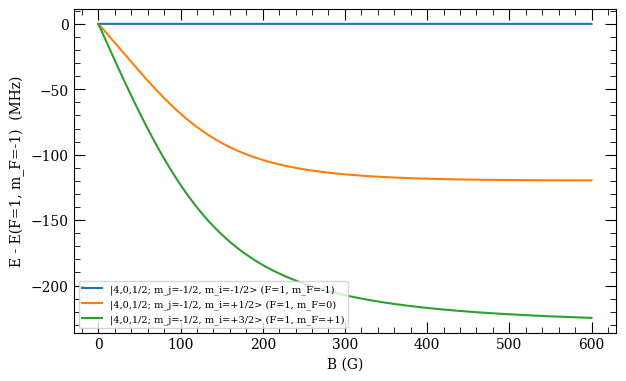

In [13]:
E_11 = res.get_energy(4, 0, 0.5, 1, -1, at=100.0)          # ints -> (F, mF)
E_hf = res.get_energy(4, 0, 0.5, -0.5, -0.5, at=100.0)     # half-integers -> (m_J, m_I): the same state
print(f"E(|1,-1>) at 100 G = {E_11/1e6:.4f} MHz;  via (m_J, m_I) = {E_hf/1e6:.4f} MHz")

f = res.get_transition_frequency((4, 0, 0.5, 1, -1), (4, 0, 0.5, 2, -2), at=[0.0, 100.0, 520.6])
print("|1,-1> -> |2,-2| at 0, 100, 520.6 G:", np.round(f / 1e6, 3), "MHz")

B_cal = res.field_from_splitting((4, 0, 0.5, 1, -1), (4, 0, 0.5, 2, -2), f_measured_hz=f[2])
print(f"field_from_splitting recovers {B_cal:.2f} G")

B, E, labels = res.field_energy(states=(4, 0, 0.5, 1))
fig, ax = plt.subplots()
for row, lbl in zip(E, labels):
    ax.plot(B, (row - E[0]) / 1e6, label=lbl)
ax.set_xlabel("B (G)"); ax.set_ylabel("E - E(F=1, m_F=-1)  (MHz)"); ax.legend(fontsize=7);

The atom object wraps the most common ground-state questions so you do not
need to build a model: transition frequency, field from a measured frequency,
and the field sensitivity. These run their own sweep internally.

In [14]:
print("f(|2,-2> -> |1,-1>) at 520.6 G:", atom.get_ground_state_transition_frequency(2, -2, 1, -1, B=520.6), "MHz")
print("field for 147.259 MHz:        ", atom.get_magnetic_field_from_ground_state_transition_frequency(2, -2, 1, -1, 147.259e6), "G")
print("sensitivity at 520.6 G:       ", atom.get_ground_state_transition_sensitivity(2, -2, 1, -1, 520.6), "MHz/G")

f(|2,-2> -> |1,-1>) at 520.6 G: 147.2590863773322 MHz
field for 147.259 MHz:         520.6012595693023 G
sensitivity at 520.6 G:        -0.06848573427331237 MHz/G


### 3.5 Optional terms

`diamagnetic=True` adds the $B^2$ term (radial integrals from ARC
wavefunctions; matters at the kHz level for the ground state at 500 G, more
for Rydberg states). `include_quadrupole=False` drops the electric-quadrupole
constant $B$ (only $j > 1/2$ manifolds have one). The atom's own convenience
methods use both.

In [15]:
res_dia = model.magnetic_sweep(B_max=600.0, dB=0.5, diamagnetic=True)
dE = res_dia.get_energy(4, 0, 0.5, 1, -1, at=520.6) - res.get_energy(4, 0, 0.5, 1, -1, at=520.6)
print(f"diamagnetic shift of |1,-1> at 520.6 G: {dE:.1f} Hz")

diamagnetic shift of |1,-1> at 520.6 G: 768.5 Hz


## 4. State labels and the adiabatic connection

At zero field the eigenstates are the hyperfine states $|F, m_F\rangle$; at
high field (Paschen–Back) they are the uncoupled $|m_J, m_I\rangle$. In
between they are neither. kamo names every tracked state by **both** ends of
its track, and the two names are tied together by the **adiabatic
connection**: follow the state as the field rises, and the $|F, m_F\rangle$ it
started as is *defined* to be the label of the $|m_J, m_I\rangle$ it ends as.

Why this is well defined: $m_F = m_J + m_I$ is conserved, and states with the
same $m_F$ never cross. So within one $m_F$ block the $k$-th lowest state at
$B=0$ stays the $k$-th lowest at every field. At $B=0$ the order is by $F$
(ascending when $A>0$, descending for an inverted manifold such as K's
$nD_{5/2}$); at high field it is by $m_J$ (ascending, since $g_J>0$). Pairing
the $k$-th lowest $F$ with the $k$-th lowest $m_J$ in each $m_F$ block gives a
bijection, the manifold's `label_map`. No diagonalization is needed for it.

Consequences worth internalizing:

* A label belongs to the **whole track**, not to a field. `res.label(i)` is the same at every step.
* The `(m_J, m_I)` in a label is the state's high-field character, **not** its largest component at the field you are looking at. At $B = 0$ the dominant uncoupled component of $|F, m_F\rangle$ is set by Clebsch–Gordan coefficients and can be a different $(m_J, m_I)$ altogether.
* `plot(states=...)`, `get_energy`, `convert_label` and the legend all use the same map, so what you ask for is what you get.

In [16]:
man = model[(4, 1, 1.5)]
print("label_map of 4P3/2 (m_J, m_I) -> (F, m_F), m_F = -1 block:")
for (mj, mi), (F, mF) in sorted(man.label_map.items()):
    if mj + mi == -1:
        print(f"   |m_J={mj:+.1f}, m_I={mi:+.1f}>  <->  |F={F}, m_F={mF:+d}>")

print()
print("state_for(F=1, mF=-1):", man.state_for(1, -1), "   label_for(-1.5, 1.5):", man.label_for(-1.5, 1.5))

label_map of 4P3/2 (m_J, m_I) -> (F, m_F), m_F = -1 block:
   |m_J=-1.5, m_I=+0.5>  <->  |F=1, m_F=-1>
   |m_J=-0.5, m_I=-0.5>  <->  |F=2, m_F=-1>
   |m_J=+0.5, m_I=-1.5>  <->  |F=3, m_F=-1>

state_for(F=1, mF=-1): (-1.5, 0.5)    label_for(-1.5, 1.5): (0, 0)


In [15]:
# The four m_J = -3/2 states of 4P3/2: at B = 0 their *dominant* uncoupled
# component is not the high-field label they carry.
for i in res.indices_for_F_or_m_j(4, 1, 1.5, -1.5):
    dom = res.dominant_state(i, step=0)
    print(f"{res.label(i):55s} dominant component at B=0: (m_J={dom.m_j:+.1f}, m_I={dom.m_i:+.1f})")

|4,1,3/2; m_j=-3/2, m_i=-3/2> (F=3, m_F=-3)             dominant component at B=0: (m_J=-1.5, m_I=-1.5)
|4,1,3/2; m_j=-3/2, m_i=-1/2> (F=2, m_F=-2)             dominant component at B=0: (m_J=-1.5, m_I=-0.5)
|4,1,3/2; m_j=-3/2, m_i=+1/2> (F=1, m_F=-1)             dominant component at B=0: (m_J=-0.5, m_I=-0.5)
|4,1,3/2; m_j=-3/2, m_i=+3/2> (F=0, m_F=0)              dominant component at B=0: (m_J=+1.5, m_I=-1.5)


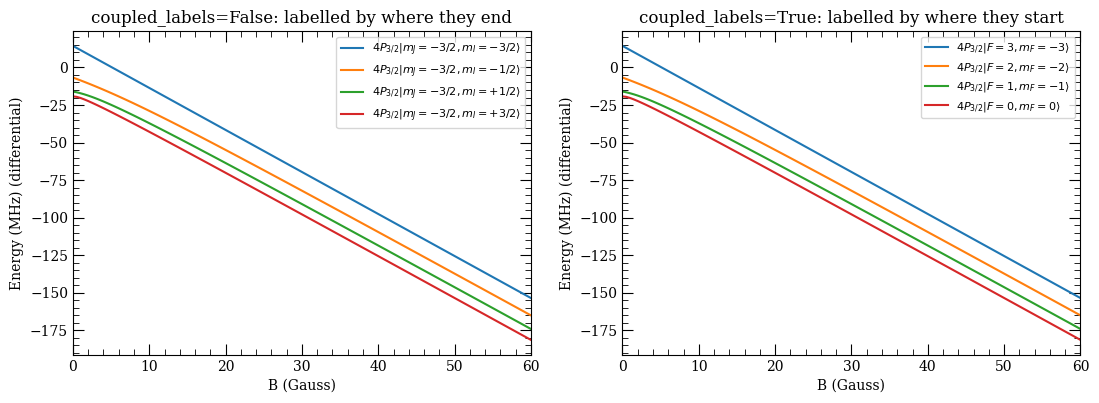

In [16]:
# Same states, drawn twice: uncoupled (high-field) legend vs coupled (zero-field) legend.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
res.plot(ax=ax[0], states=(4, 1, 1.5, -1.5), plot_differential=(4, 1, 1.5), xlim=(0, 60))
ax[0].set_title("coupled_labels=False: labelled by where they end")
res.plot(ax=ax[1], states=(4, 1, 1.5, -1.5), plot_differential=(4, 1, 1.5), xlim=(0, 60), coupled_labels=True)
ax[1].set_title("coupled_labels=True: labelled by where they start");

The same map converts labels outside a sweep. `state_label` renders a term
symbol and ket, converting between the two bases on request. `convert_label`
on a sweep result flips a 5-tuple. `is_coupled` tells you how a pair of
magnetic quantum numbers will be read for a given nuclear spin.

In [17]:
print(state_label(4, 0, 0.5, 1, -1))                          # as given: coupled
print(state_label(4, 0, 0.5, 1, -1, basis="uncoupled"))       # converted
print(state_label(4, 1, 1.5, -1.5, 0.5, basis="coupled"))
print(state_label(4, 0, 0.5, 2, tex=False))                    # one number: F
print(res.convert_label((4, 0, 0.5, 2, -1)), res.convert_label((4, 0, 0.5, 0.5, -1.5)))
print("is_coupled(1, -1, I=3/2):", is_coupled(1, -1, 1.5), "  is_coupled(0.5, -1.5, I=3/2):", is_coupled(0.5, -1.5, 1.5))
print(atom.state_label(4, 0, 0.5, 1, -1, force_hf_lf="hf"))    # the atom's wrapper: no $ delimiters

$4S_{1/2}|F=1, m_F=-1\rangle$
$4S_{1/2}|m_J=-1/2, m_I=-1/2\rangle$
$4P_{3/2}|F=1, m_F=-1\rangle$
4S_1/2|F=2⟩
(4, 0, 0.5, 0.5, -1.5) (4, 0, 0.5, 2, -1)
is_coupled(1, -1, I=3/2): True   is_coupled(0.5, -1.5, I=3/2): False
4S_{1/2}|m_J=-1/2, m_I=-1/2\rangle


A manifold with no hyperfine constant in kamo's data ($l \ge 3$, or a core
orbital) has no $|F, m_F\rangle$ labels: $F$ is not a good quantum number
without an $\mathbf{I}\cdot\mathbf{J}$ term, so such states are labelled by
$(m_J, m_I)$ only and a warning says so if you ask for the coupled form.

## 5. Laser sweep

A laser sweep holds the magnetic field fixed and ramps the intensity from 0 to
`I_max`, tracking states the same way. Two things to decide first:

1. **Which manifolds to include.** The light shift of a state comes from every
   dipole-allowed channel; at 1064 nm the 4S shift is dominated by 4P but the
   4P shift by 3D and 5S. `light_shift_basis(states, frequency, atom=...)`
   ranks the channels and returns the manifolds carrying at least `tol` of the
   polarizability.
2. **Which model.** `model="auto"` (default) picks the second-order
   `"perturbative"` model when the light is far detuned and the rotating-wave
   `"rwa"` dipole coupling when it is not; `"stark"` uses effective
   polarizability operators. `choose_laser_model` explains the choice.

`B_gauss` is the field the laser sweep runs at; take it from a magnetic sweep
with `res.field_at(...)` so the two calculations agree at intensity zero.

In [18]:
beam = GaussianBeam(waist=3e-6, wavelength=1064e-9, power=50e-6)   # a 1064 nm tweezer
B_lab = 520.6
g_up, e_up = (4, 0, 0.5, -0.5, -0.5), (4, 1, 1.5, -1.5, -0.5)      # the sigma- imaging pair at high field

sel = light_shift_basis((g_up, e_up), beam.frequency(), atom=atom, B_gauss=B_lab)
print(sel.describe())
choice = choose_laser_model((g_up, e_up), beam.frequency(), intensity_W_m2=beam.I0, B_gauss=B_lab, atom=atom)
print(choice.describe())

basis [4s0.5, 4p0.5, 4p1.5, 5s0.5, 3d2.5, 3d1.5, 6s0.5]; polarizability coverage 4s0.5: 0.9894 (core 0.0091), 4p1.5: 0.9963 (core 0.0018)
laser_model='perturbative': perturbative light; exact eigenstates with both rotating terms (eps_rwa~8.0e-02, eps_perturbative~1.7e-08, eps_stark~5.6e-05, eta=1.3e-04); basis [4s0.5, 4p0.5, 4p1.5, 5s0.5, 3d2.5, 3d1.5, 6s0.5]; polarizability coverage 4s0.5: 0.9894 (core 0.0091), 4p1.5: 0.9963 (core 0.0018)


model used: model='perturbative': perturbative light; exact eigenstates with both rotating terms (eta=4.2e-05, eps_rwa~4.7e-02, eps_perturbative~1.8e-09)
intensity grid: 0.0 -> 3.537e+06 W/m^2  (0.4 kW/cm^2)


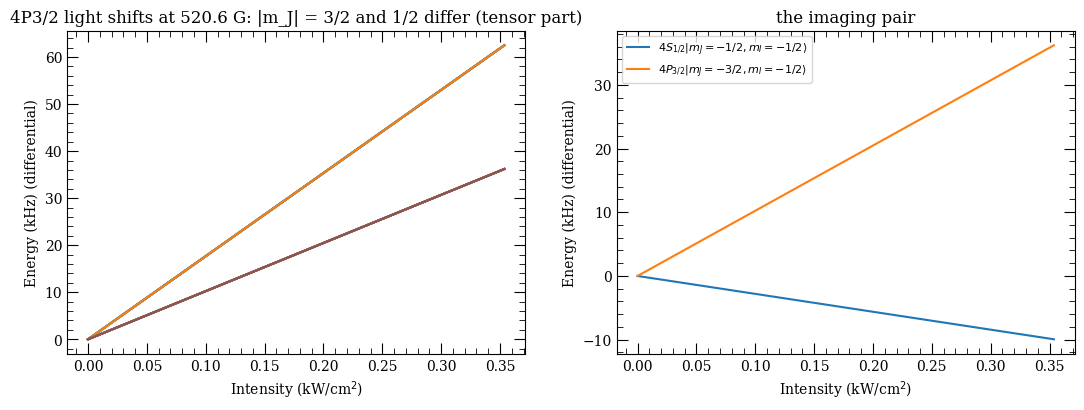

In [20]:
model_L = AtomicStructure(list(sel.manifolds), atom=atom)
resL = model_L.laser_sweep(beam, I_max=beam.I0, n_points=40, B_gauss=B_lab, polarization="pi")
print("model used:", resL.model_choice.describe() if resL.model_choice is not None else "explicit")
print("intensity grid:", resL.param[0], "->", f"{resL.param[-1]:.3e} W/m^2  ({resL.param[-1] / 1e7:.1f} kW/cm^2)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
resL.plot(ax=ax[0], states=(4, 1, 1.5), plot_differential=True, x_unit="kW/cm^2", energy_unit="kHz",
          label_states=False)
ax[0].set_title("4P3/2 light shifts at 520.6 G: |m_J| = 3/2 and 1/2 differ (tensor part)")
resL.plot(ax=ax[1], states=[g_up, e_up], plot_differential=True, x_unit="kW/cm^2", energy_unit="kHz")
ax[1].set_title("the imaging pair");

In [20]:
# The differential shift of the imaging transition, and the intensity that gives a target shift.
shift = resL.transition_frequency_shift(g_up, e_up)
print(f"imaging-line shift at full power: {shift[-1] / 1e3:.2f} kHz")
I_target = resL.intensity_from_splitting_shift(g_up, e_up, df_measured_hz=shift[-1] / 2)
print(f"half of that shift needs {I_target:.3e} W/m^2 = {I_target / 1e7:.2f} kW/cm^2")

# The atom wraps the whole magnetic + laser chain for one transition:
f_shift = atom.get_transition_frequency(g_up, e_up, B=B_lab, beam=beam, relative_mode="optical")
print(f"atom.get_transition_frequency(..., relative_mode='optical'): {f_shift / 1e3:.2f} kHz")

imaging-line shift at full power: 46.13 kHz
half of that shift needs 1.768e+06 W/m^2 = 0.18 kW/cm^2


atom.get_transition_frequency(..., relative_mode='optical'): 46.13 kHz


Far from resonance and with π light the ground-state shift is scalar, so all
eight $4S_{1/2}$ lines would lie on top of each other; the $4P_{3/2}$ shifts
differ by $m_J$ through the tensor polarizability. Polarization is given as
`"pi"`, `"sigma+"`, `"sigma-"` (relative to the quantization axis, which is
the magnetic field) or a complex 3-vector. The sweep result also offers
`scattering_rate(...)` and `dominant_couplings()` for a near-resonant beam
driven with the RWA model.

## 6. A different atom

Everything above takes `atom=`. Build another alkali with the species string
factory or the class, and pass it to `AtomicStructure` (or to the atom's own
convenience methods). The ground n changes (5 for Rb, 6 for Cs), hyperfine
constants come from the portal where it has them and from ARC otherwise, and
$B$ always from ARC.

Rubidium87(use_portal=True, portal_species='Rb1')   I = 1.5   ground: (5, 0, 0.5)
    5s1/2: A = 3417.34131 MHz [portal (measured)], B = 0 MHz [exact (J = 1/2)]
    5p3/2: A = 84.72 MHz [portal (measured)], B = 12.4965 MHz [arc]
Caesium(use_portal=True, portal_species='Cs1')   I = 3.5   ground: (6, 0, 0.5)
    6s1/2: A = 2298.15794 MHz [portal (measured)], B = 0 MHz [exact (J = 1/2)]
    6p3/2: A = 50.28163 MHz [portal (measured)], B = -0.53 MHz [arc]
Rb87 clock transition |1,0> -> |2,0> at 0 G: 6.834682614 GHz


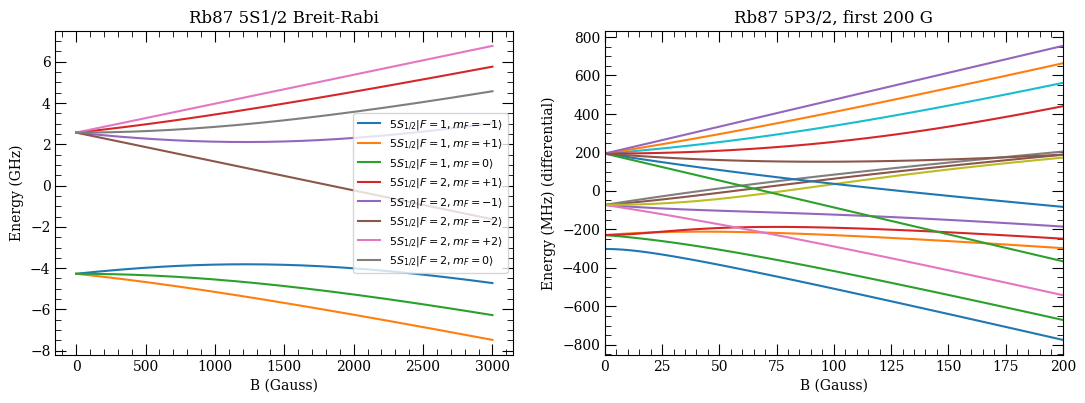

In [21]:
from kamo import atom as make_atom, Rubidium87

rb = make_atom("Rb87")            # also "87Rb", "Rb-87", Rubidium87()
cs = make_atom("Cs")
for a in (rb, cs):
    n0 = a.groundStateN
    print(a, "  I =", a.I, "  ground:", a.ground_state)
    print("   ", a.hyperfine_constants(n0, 0, 0.5))
    print("   ", a.hyperfine_constants(n0, 1, 1.5))

model_rb = AtomicStructure([(5, 0, 0.5), (5, 1, 0.5), (5, 1, 1.5)], atom=rb)
res_rb = model_rb.magnetic_sweep(B_max=3000.0, dB=2.0)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
res_rb.plot(ax=ax[0], states=(5, 0, 0.5), coupled_labels=True, energy_unit="GHz")
ax[0].set_title("Rb87 5S1/2 Breit-Rabi")
res_rb.plot(ax=ax[1], states=(5, 1, 1.5), plot_differential=(5, 1, 1.5), label_states=False, xlim=(0, 200))
ax[1].set_title("Rb87 5P3/2, first 200 G");
print("Rb87 clock transition |1,0> -> |2,0> at 0 G:",
      res_rb.get_transition_frequency((5, 0, 0.5, 1, 0), (5, 0, 0.5, 2, 0), at=0.0) / 1e9, "GHz")

### Integer nuclear spin (Li6, K40)

For $I = 1$ (Li6) or $I = 4$ (K40) the parities swap: $F$ and $m_F$ are
half-integers, $m_I$ is an integer. The rule kamo actually applies is
"the second number has the parity of $I$ → it is $m_I$, the pair is
uncoupled; otherwise the pair is $(F, m_F)$", which reduces to the familiar
integer/half-integer rule for $I = 3/2$. `atom.coupled_qn(F, mF)` returns the
pair in the right type for the atom.

Li6: I = 1.0  coupled_qn(3/2, -3/2) = (1.5, -1.5)   is_coupled(1.5, -1.5, I=1): True   is_coupled(0.5, 1, I=1): False
$2S_{1/2}|F=3/2, m_F=-3/2\rangle$  ->  $2S_{1/2}|m_J=-1/2, m_I=-1\rangle$
Li6 ground splitting: 228.2052585 MHz


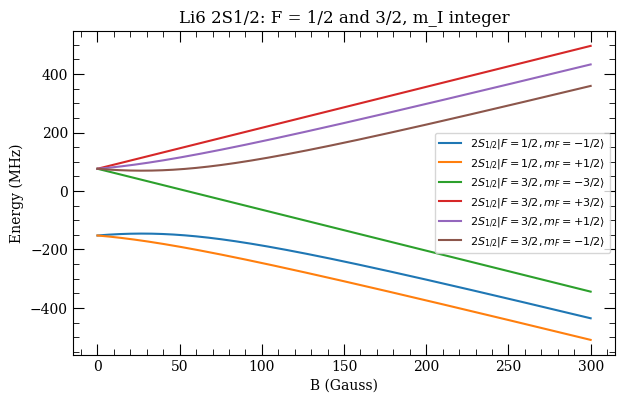

In [22]:
li = make_atom("Li6")
print("Li6: I =", li.I, " coupled_qn(3/2, -3/2) =", li.coupled_qn(1.5, -1.5),
      "  is_coupled(1.5, -1.5, I=1):", is_coupled(1.5, -1.5, 1.0), "  is_coupled(0.5, 1, I=1):", is_coupled(0.5, 1, 1.0))
print(state_label(2, 0, 0.5, 1.5, -1.5, atom=li), " -> ", state_label(2, 0, 0.5, 1.5, -1.5, atom=li, basis="uncoupled"))

res_li = AtomicStructure([(2, 0, 0.5)], atom=li).magnetic_sweep(B_max=300.0, dB=0.5)
fig, ax = res_li.plot(coupled_labels=True)
ax.set_title("Li6 2S1/2: F = 1/2 and 3/2, m_I integer");
print("Li6 ground splitting:", (res_li.energies[0].max() - res_li.energies[0].min()) / 1e6, "MHz")

Caveats for the non-potassium atoms:

* ARC's level tables are per **element**, so isotope shifts are missing: Li6
  D lines are 10.8 GHz off, K40 and K41 by 0.1–0.2 GHz. Hyperfine and Zeeman
  structure is per isotope and correct.
* `kamo.scattering` (scattering lengths, Feshbach resonances) is 39K only and
  raises for any other atom.
* `use_portal=False` on any atom gives pure ARC data (E1 and hyperfine).
* The default atom for every `atom=None` in the package is `Potassium39()`.

## 7. Things worth knowing

Collected while writing this notebook.

**Units and conventions**
* Energies are Hz everywhere in the API ($E/h$); only `plot` rescales. Fields are Gauss. Intensities are W/m²; `x_unit="mW/cm^2"` divides by 10.
* A 5-tuple with two integers is $(F, m_F)$; with two half-integers it is $(m_J, m_I)$ (swapped parity for integer $I$). A 4-tuple's last number is $F$ if integer, $m_J$ if half-integer. Mixed parities raise.
* `(m_J, m_I)` in a label is the **high-field** character the state connects to, never the largest component at the current field.

**Building models**
* Order matters: fine-structure energies are referenced to the first manifold, and the plot of a raw sweep shows that offset. Use `plot_differential=(n, l, j)` to see hyperfine + Zeeman structure only.
* Duplicated manifolds raise; core orbitals are excluded by `make_nlj_basis` but not by hand-written tuples (ARC gives them meaningless energies).
* Reuse one atom object: each `AtomicStructure` accepts `atom=`, and the default builds a new `Potassium39()` only once per process.
* The basis for a **laser** sweep must contain the channel manifolds (`light_shift_basis`); a basis with only 4S and 4P gives the wrong 4P light shift at 1064 nm.

**Sweeps**
* `dB` is the tracking resolution, not just plot resolution. Rule of thumb: a few percent of $A/(1.4\ \mathrm{MHz/G})$ for the narrowest hyperfine structure in the basis. Watch for `RuntimeWarning`s.
* `get_energy(..., at=B)` interpolates linearly between grid points; for kHz precision at one field, sweep with a fine `dB` or straight to that field.
* `magnetic_sweep` always starts at 0 G. To get a laser sweep at a field, pass `B_gauss=res.field_at(B)`.
* `plot` returns `(fig, ax)`; pass `ax=` to compose panels. `xlim` rescales y to the visible data; `label_states=False` for large bases.
* `field_energy(states=...)` gives `(B, energies[n_states, n_steps], labels)` for your own figures.

**Atoms**
* `atom.hyperfine_constants(n, l, j)` shows the source of $A$ and $B$; `getHFSCoefficients` is ARC's interface to the same numbers (Hz).
* `atom.g_J(l, j, n=)` is measured for the ground state and Landé otherwise; `atom.gI` is the shielded atomic value with its reference in the isotope table (`kamo.atom_properties.alkali.ISOTOPES`).
* The atom's own `get_transition_energy` and `get_transition_sensitivity` (signed `E2 - E1` in MHz and its slope in MHz/G for any two states, vectorized over B; `get_ground_state_transition_frequency`, `get_ground_state_transition_sensitivity` and `get_transition_shift` are their special cases), `get_magnetic_field_from_ground_state_transition_frequency`, `get_transition_frequency` and `get_intensity_from_light_shift` run these sweeps for you and accept the same state tuples.
* Portal data is bundled for Li, Na, K, Rb and Cs, so all of this runs offline; a warning about the portal being unreachable just means the bundled snapshot was used.